# Brain Tumor MRI Dataset — Final Dataset Analysis (Train / Val / Test)

This notebook analyzes your **already-finalized** dataset
(`Brain_Tumor_MRI_Dataset_Final.zip`, 107.1 MB) — the one you exported with the
70% Train / 15% Val / 15% Test split.

It does **not** rebuild or re-split anything. It:

1. Loads the exported ZIP and re-verifies the folder structure.
2. Counts images per class, per split.
3. Re-confirms **zero data leakage** across Train/Val/Test (content-hash check) —
   a final integrity check worth having on record before publishing.
4. Produces a full distribution report (bar charts, pie chart, donut chart,
   heatmap, summary table) in the same style as your original dataset analysis,
   now covering all **three** splits.
5. Attaches your model benchmark results as a companion table + chart.
6. Regenerates the dataset card (`README.md`) with the final numbers and
   benchmark results baked in, and re-packages everything if you want a fresh
   copy to publish.


## Step 0 — Install & import dependencies

In [1]:
!pip install tqdm -q

import os, shutil, hashlib, zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("✅ Environment ready")


✅ Environment ready


## Step 1 — Upload the final dataset ZIP

Upload `Brain_Tumor_MRI_Dataset_Final.zip` (the file you just exported).


In [2]:
from google.colab import files

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

DATASET_ROOT = 'Brain_Tumor_MRI_Dataset_Final'
if os.path.exists(DATASET_ROOT):
    shutil.rmtree(DATASET_ROOT)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(DATASET_ROOT)

# Handle the case where the zip contains a single nested root folder
contents = os.listdir(DATASET_ROOT)
if len(contents) == 1 and os.path.isdir(os.path.join(DATASET_ROOT, contents[0])):
    nested = os.path.join(DATASET_ROOT, contents[0])
    if set(os.listdir(nested)) & {'train', 'val', 'test'}:
        DATASET_ROOT = nested

print(f"✅ Extracted to: {DATASET_ROOT}")
print("Top-level contents:", os.listdir(DATASET_ROOT))


Saving Brain_Tumor_MRI_Dataset_Final.zip to Brain_Tumor_MRI_Dataset_Final.zip
✅ Extracted to: Brain_Tumor_MRI_Dataset_Final
Top-level contents: ['README.md', 'class_distribution.csv', 'class_distribution_final.png', 'model_benchmark.csv', 'test', 'model_benchmark.png', 'val', 'train']


## Step 2 — Discover splits, classes, and every image


In [3]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

SPLIT_NAMES = [d for d in ['train', 'val', 'test'] if os.path.isdir(os.path.join(DATASET_ROOT, d))]
assert SPLIT_NAMES, f"No train/val/test folders found under {DATASET_ROOT}"

records = []
for split in SPLIT_NAMES:
    split_dir = os.path.join(DATASET_ROOT, split)
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(IMG_EXTS):
                records.append({'filepath': os.path.join(cls_dir, fname), 'split': split, 'class': cls})

df = pd.DataFrame(records)
assert len(df) > 0, "No images found — check the folder structure inside the zip."
CLASSES = sorted(df['class'].unique())

print(f"📦 {len(df)} images  |  {len(CLASSES)} classes  |  splits: {SPLIT_NAMES}")
print(df.groupby(['split', 'class']).size())


📦 5941 images  |  4 classes  |  splits: ['train', 'val', 'test']
split  class     
test   glioma         328
       meningioma     221
       no_tumor       118
       pituitary      222
train  glioma        1534
       meningioma    1035
       no_tumor       551
       pituitary     1040
val    glioma         329
       meningioma     222
       no_tumor       118
       pituitary      223
dtype: int64


## Step 3 — Final leakage check (content hash)

A last confirmation, on the actual exported dataset, that no image appears in more
than one split.


In [4]:
def md5_of_file(path, chunk_size=1 << 16):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(chunk_size), b''):
            h.update(block)
    return h.hexdigest()

tqdm.pandas(desc="Hashing files")
df['md5'] = df['filepath'].progress_apply(md5_of_file)

dup_hashes = df.groupby('md5')['split'].nunique()
leaking_hashes = dup_hashes[dup_hashes > 1]

if len(leaking_hashes) > 0:
    print(f"❌ LEAKAGE DETECTED: {len(leaking_hashes)} image(s) appear in more than one split!")
    display(df[df['md5'].isin(leaking_hashes.index)].sort_values('md5')[['filepath', 'split', 'class']])
else:
    print("✅ No leakage: every image's content hash appears in exactly one split.")

within_split_dupes = df.duplicated(subset='md5').sum()
print(f"ℹ️ Exact-duplicate files still present overall (should be 0 if dedup already ran): {within_split_dupes}")


Hashing files:   0%|          | 0/5941 [00:00<?, ?it/s]

✅ No leakage: every image's content hash appears in exactly one split.
ℹ️ Exact-duplicate files still present overall (should be 0 if dedup already ran): 0


## Step 4 — Summary statistics table

In [5]:
counts = df.groupby(['class', 'split']).size().unstack(fill_value=0)
for s in SPLIT_NAMES:
    if s not in counts.columns:
        counts[s] = 0
counts = counts[SPLIT_NAMES]
counts['Total'] = counts.sum(axis=1)
counts['Overall %'] = (counts['Total'] / counts['Total'].sum() * 100).round(1)
counts.loc['TOTAL'] = counts.sum()
counts.loc['TOTAL', 'Overall %'] = 100.0

print(counts)

total_images = int(counts.loc['TOTAL', 'Total'])
split_totals = {s: int(counts.loc['TOTAL', s]) for s in SPLIT_NAMES}
split_pcts = {s: round(split_totals[s] / total_images * 100, 1) for s in SPLIT_NAMES}

print(f"\nTotal images: {total_images}")
for s in SPLIT_NAMES:
    print(f"  {s.capitalize()}: {split_totals[s]} ({split_pcts[s]}%)")


split        train    val   test   Total  Overall %
class                                              
glioma      1534.0  329.0  328.0  2191.0       36.9
meningioma  1035.0  222.0  221.0  1478.0       24.9
no_tumor     551.0  118.0  118.0   787.0       13.2
pituitary   1040.0  223.0  222.0  1485.0       25.0
TOTAL       4160.0  892.0  889.0  5941.0      100.0

Total images: 5941
  Train: 4160 (70.0%)
  Val: 892 (15.0%)
  Test: 889 (15.0%)


## Step 5 — Full distribution report (bar / pie / donut / heatmap)

Same visual style as your original dataset analysis, extended to cover Train, Val,
and Test.


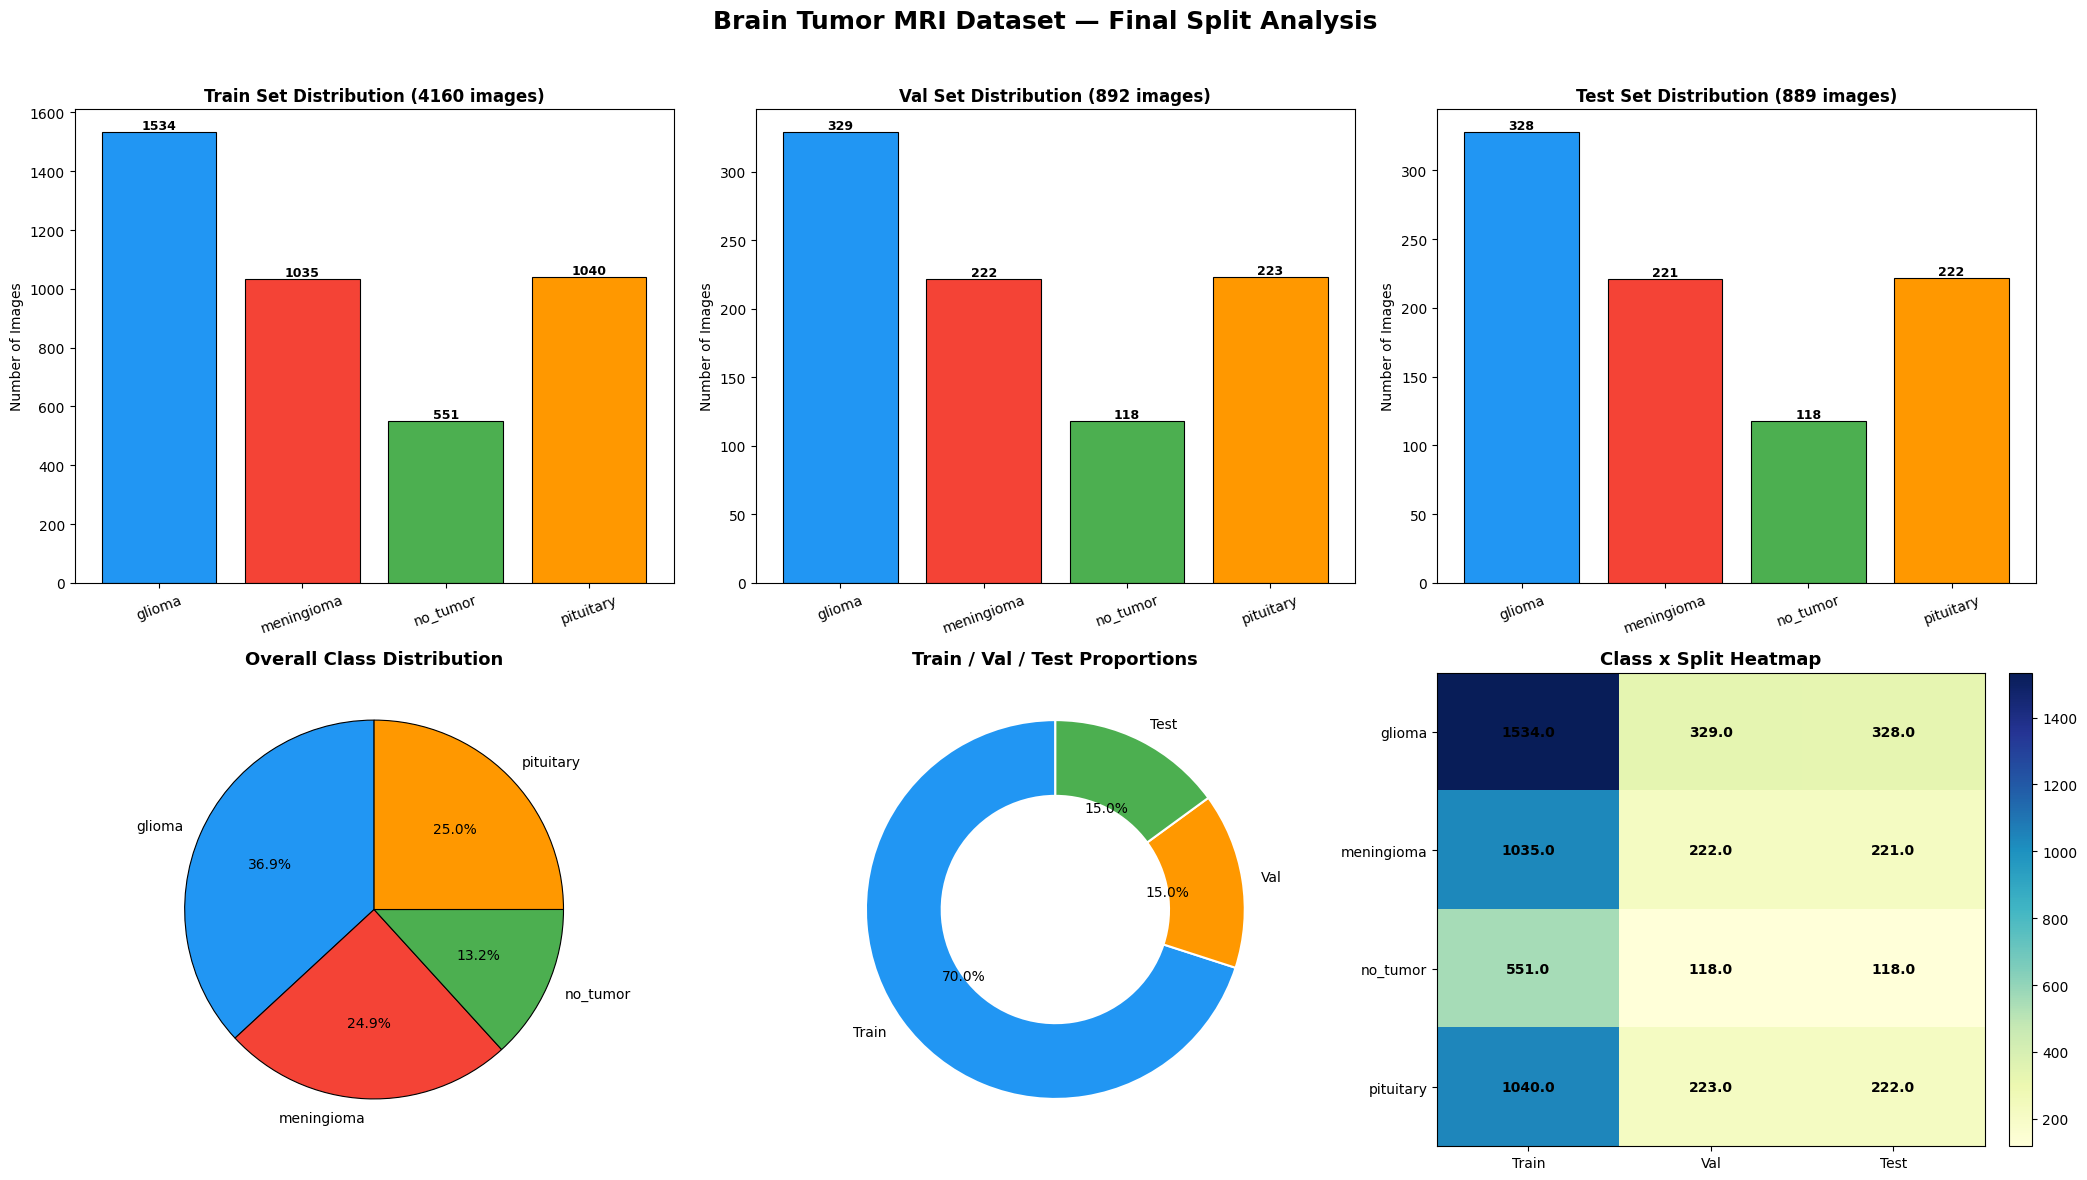

✅ Saved figure: final_dataset_distribution.png


In [6]:
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
class_colors = {cls: colors[i % len(colors)] for i, cls in enumerate(CLASSES)}
split_colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

n_splits = len(SPLIT_NAMES)
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('Brain Tumor MRI Dataset — Final Split Analysis', fontsize=18, fontweight='bold')

# Row 1, cols 0..n_splits-1: bar chart per split
for i, split in enumerate(SPLIT_NAMES):
    ax = axes[0][i]
    vals = counts.loc[CLASSES, split]
    bars = ax.bar(CLASSES, vals, color=[class_colors[c] for c in CLASSES], edgecolor='black', linewidth=0.8)
    ax.set_title(f'{split.capitalize()} Set Distribution ({int(vals.sum())} images)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=20)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, str(int(v)), ha='center', va='bottom', fontsize=9, fontweight='bold')

# If fewer than 3 splits, hide unused axes in row 1
for j in range(n_splits, 3):
    axes[0][j].axis('off')

# Row 2, col 0: overall pie
overall = counts.loc[CLASSES, 'Total']
axes[1][0].pie(overall, labels=CLASSES, autopct='%1.1f%%', colors=[class_colors[c] for c in CLASSES],
               startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1][0].set_title('Overall Class Distribution', fontsize=13, fontweight='bold')

# Row 2, col 1: nested donut — outer ring = split sizes, inner rings = per-class within split
outer_vals = [split_totals[s] for s in SPLIT_NAMES]
axes[1][1].pie(outer_vals, labels=[s.capitalize() for s in SPLIT_NAMES], autopct='%1.1f%%',
               colors=[split_colors[s] for s in SPLIT_NAMES], startangle=90, radius=1.0,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'width': 0.4})
axes[1][1].set_title('Train / Val / Test Proportions', fontsize=13, fontweight='bold')

# Row 2, col 2: heatmap (class x split)
heat = counts.loc[CLASSES, SPLIT_NAMES].values
im = axes[1][2].imshow(heat, cmap='YlGnBu', aspect='auto')
axes[1][2].set_xticks(range(n_splits)); axes[1][2].set_xticklabels([s.capitalize() for s in SPLIT_NAMES])
axes[1][2].set_yticks(range(len(CLASSES))); axes[1][2].set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(n_splits):
        axes[1][2].text(j, i, str(heat[i, j]), ha='center', va='center', fontsize=10, fontweight='bold')
axes[1][2].set_title('Class x Split Heatmap', fontsize=13, fontweight='bold')
fig.colorbar(im, ax=axes[1][2], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('final_dataset_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Saved figure: final_dataset_distribution.png")


## Step 6 — Per-class split-balance check

Confirms every class was split at ~70/15/15 individually (not just in aggregate) —
this is what "equally distributed" split means in practice.


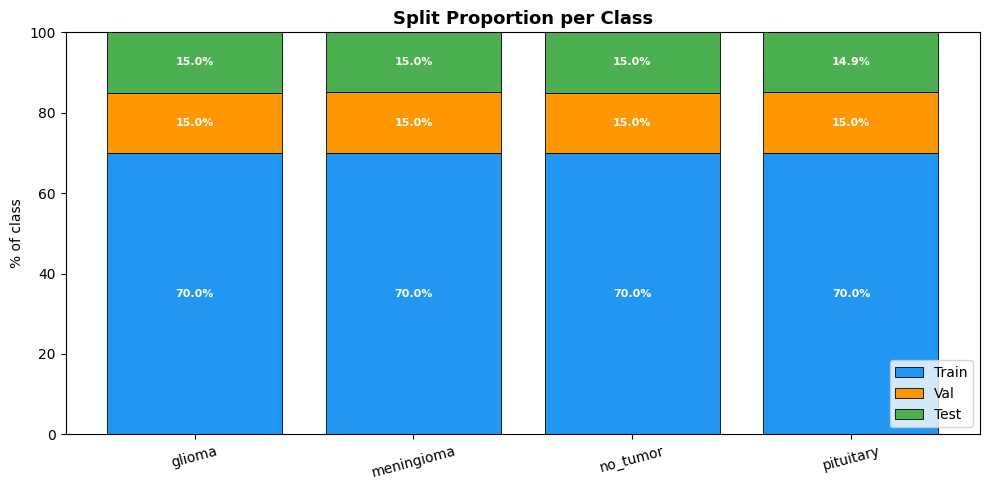

split       train   val  test
class                        
glioma       70.0  15.0  15.0
meningioma   70.0  15.0  15.0
no_tumor     70.0  15.0  15.0
pituitary    70.0  15.0  14.9

✅ Saved figure: split_balance_per_class.png


In [7]:
props = counts.loc[CLASSES, SPLIT_NAMES].div(counts.loc[CLASSES, 'Total'], axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(CLASSES))
for split in SPLIT_NAMES:
    ax.bar(CLASSES, props[split], bottom=bottom, label=split.capitalize(),
           color=split_colors[split], edgecolor='black', linewidth=0.6)
    bottom += props[split].values
ax.set_ylim(0, 100)
ax.set_ylabel('% of class')
ax.set_title('Split Proportion per Class', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=15)
for i, cls in enumerate(CLASSES):
    y = 0
    for split in SPLIT_NAMES:
        v = props.loc[cls, split]
        ax.text(i, y + v / 2, f'{v:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        y += v
plt.tight_layout()
plt.savefig('split_balance_per_class.png', dpi=200, bbox_inches='tight')
plt.show()

print(props.round(1))
print("\n✅ Saved figure: split_balance_per_class.png")


## Step 7 — Model benchmark results

Your training run results, recorded alongside the dataset for the published card.


,Architecture,Paradigm,Test Acc.,Test F1
0,CNN,From scratch,0.8470,0.8457
1,ViT,From scratch,0.8256,0.8240
2,Hybrid CNN–ViT,From scratch,0.8189,0.8201
3,ResNet50,Frozen pretrained,0.8031,0.8022
4,DenseNet121,Frozen pretrained,0.8706,0.8703
5,ResNet50,Fine-tuned,0.9708,0.9708
6,DenseNet121,Fine-tuned,0.9831,0.9831


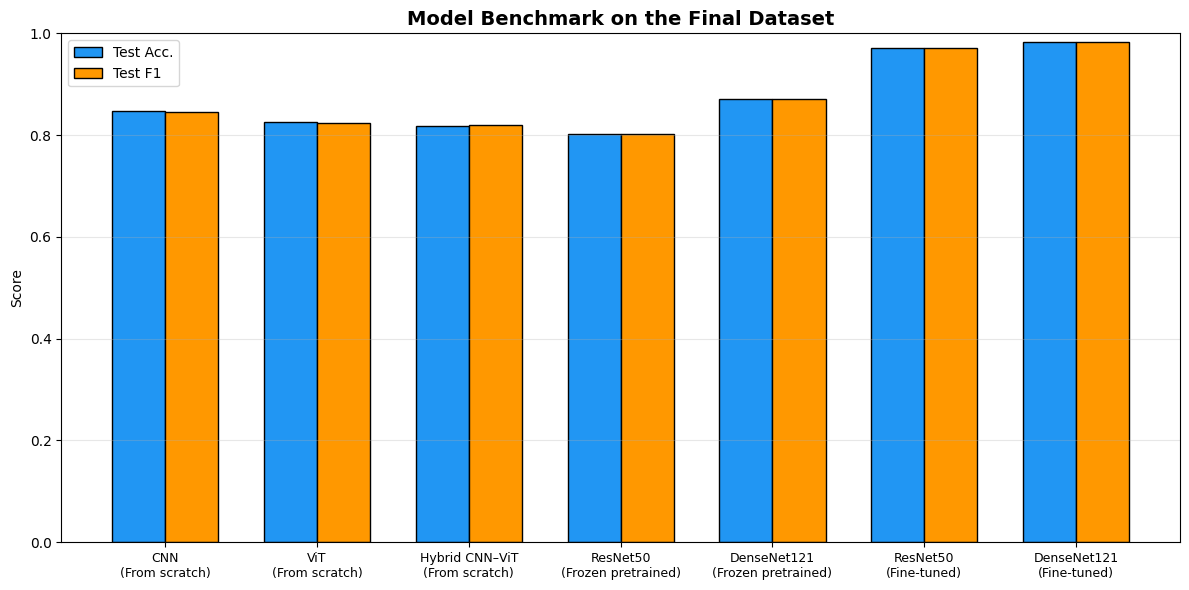

In [8]:
results_df = pd.DataFrame([
    {'Architecture': 'CNN',            'Paradigm': 'From scratch',      'Test Acc.': 0.8470, 'Test F1': 0.8457},
    {'Architecture': 'ViT',            'Paradigm': 'From scratch',      'Test Acc.': 0.8256, 'Test F1': 0.8240},
    {'Architecture': 'Hybrid CNN–ViT', 'Paradigm': 'From scratch',      'Test Acc.': 0.8189, 'Test F1': 0.8201},
    {'Architecture': 'ResNet50',       'Paradigm': 'Frozen pretrained', 'Test Acc.': 0.8031, 'Test F1': 0.8022},
    {'Architecture': 'DenseNet121',    'Paradigm': 'Frozen pretrained', 'Test Acc.': 0.8706, 'Test F1': 0.8703},
    {'Architecture': 'ResNet50',       'Paradigm': 'Fine-tuned',        'Test Acc.': 0.9708, 'Test F1': 0.9708},
    {'Architecture': 'DenseNet121',    'Paradigm': 'Fine-tuned',        'Test Acc.': 0.9831, 'Test F1': 0.9831},
])

def highlight_best(s):
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

display(results_df.style.apply(highlight_best, subset=['Test Acc.', 'Test F1']).format({'Test Acc.': '{:.4f}', 'Test F1': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35
labels = [f"{r['Architecture']}\n({r['Paradigm']})" for _, r in results_df.iterrows()]

ax.bar(x - width/2, results_df['Test Acc.'], width, label='Test Acc.', color='#2196F3', edgecolor='black')
ax.bar(x + width/2, results_df['Test F1'], width, label='Test F1', color='#FF9800', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Benchmark on the Final Dataset', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()


# dimensions & file size (full population)

In [9]:
from PIL import Image

def get_dims_and_size(path):
    try:
        with Image.open(path) as img:
            w, h = img.size
        size_kb = os.path.getsize(path) / 1024
        return pd.Series({'width': w, 'height': h, 'filesize_kb': size_kb})
    except Exception:
        return pd.Series({'width': np.nan, 'height': np.nan, 'filesize_kb': np.nan})

tqdm.pandas(desc="Reading image dimensions")
dims_df = df['filepath'].progress_apply(get_dims_and_size)
df = pd.concat([df, dims_df], axis=1)
df = df.dropna(subset=['width', 'height', 'filesize_kb']).reset_index(drop=True)

print(f"✅ Read dimensions/file size for {len(df)} images")

# Table: mean/std width, height, file size per class (full population)
img_props = df.groupby('class').agg(
    width_mean=('width', 'mean'), width_std=('width', 'std'),
    height_mean=('height', 'mean'), height_std=('height', 'std'),
    filesize_mean=('filesize_kb', 'mean'), filesize_std=('filesize_kb', 'std'),
).round(2)
print("\n=== Table: Native image dimensions & file size (full population, N=%d) ===" % len(df))
print(img_props)

# Table: file size quartiles per class
filesize_range = df.groupby('class')['filesize_kb'].agg(
    min='min', q1=lambda x: x.quantile(0.25), median='median', max='max'
).round(2)
print("\n=== Table: File size distribution (KB) per class ===")
print(filesize_range)

# Table: top 10 most frequent resolutions
res_counts = df.groupby(['width', 'height']).size().sort_values(ascending=False).head(10)
res_pct = (res_counts / len(df) * 100).round(1)
print("\n=== Table: Top 10 native resolutions ===")
for (w, h), cnt in res_counts.items():
    print(f"{w} x {h}: {cnt} images ({res_pct[(w, h)]}%)")

Reading image dimensions:   0%|          | 0/5941 [00:00<?, ?it/s]

✅ Read dimensions/file size for 5941 images

=== Table: Native image dimensions & file size (full population, N=5941) ===
            width_mean  width_std  height_mean  height_std  filesize_mean  \
class                                                                       
glioma          405.50     138.80       406.02      138.82          15.71   
meningioma      416.82     138.18       418.31      137.69          18.34   
no_tumor        290.62     153.47       293.67      144.12          19.50   
pituitary       416.33     135.90       416.31      135.81          23.54   

            filesize_std  
class                     
glioma              8.34  
meningioma         11.08  
no_tumor           23.61  
pituitary          12.80  

=== Table: File size distribution (KB) per class ===
             min    q1  median     max
class                                 
glioma      3.31  6.88   16.32   70.21
meningioma  4.08  8.17   19.21  227.59
no_tumor    3.39  7.72   11.93  275.97
pitu

# ## Step 6C — Representative sample image per class

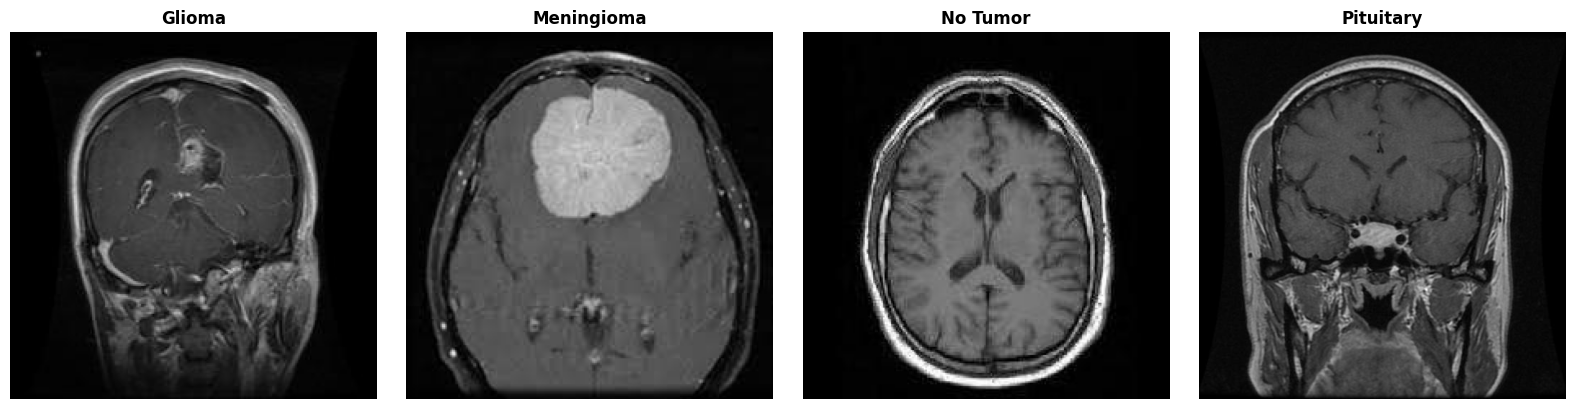

✅ Saved figure: Sample_Image.png


In [10]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(4 * len(CLASSES), 4))
if len(CLASSES) == 1:
    axes = [axes]

rng = np.random.RandomState(SEED if 'SEED' in dir() else 42)
for ax, cls in zip(axes, CLASSES):
    sample_path = df[df['class'] == cls]['filepath'].sample(1, random_state=42).values[0]
    img = Image.open(sample_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('Sample_Image.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved figure: Sample_Image.png")

## Step 6D — Pixel-intensity histograms (training split, per class)

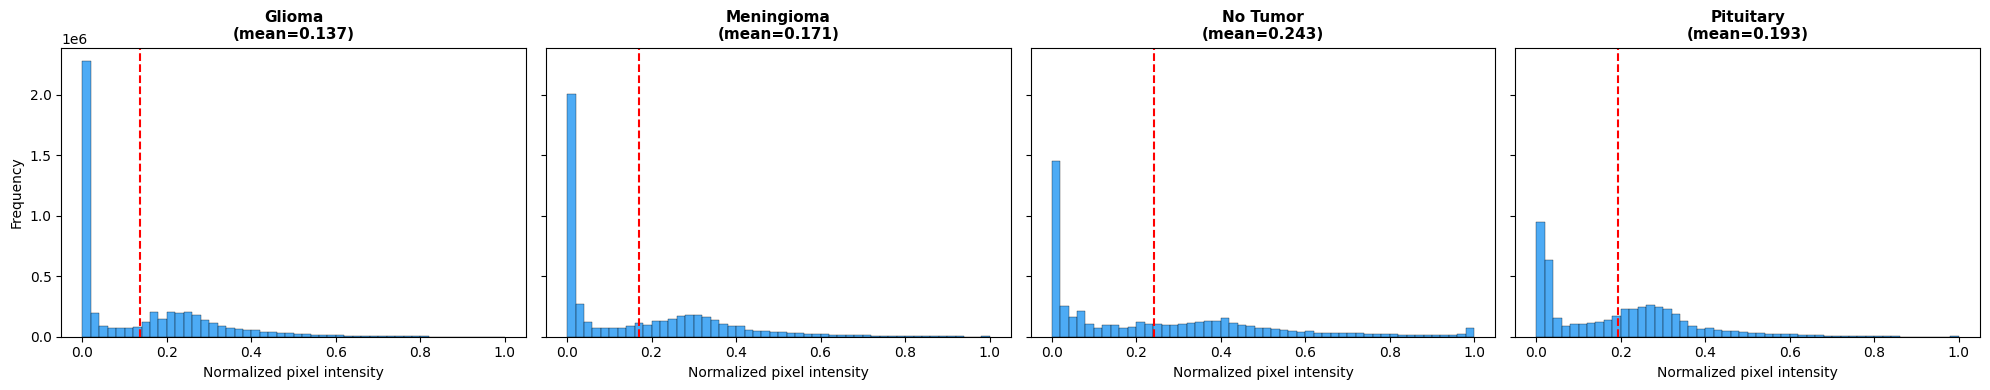

Class-wise mean intensity:
  glioma: 0.137
  meningioma: 0.171
  no_tumor: 0.243
  pituitary: 0.193


In [11]:
N_PER_CLASS = 100  # matches original methodology; raise if you want tighter estimates

train_df = df[df['split'] == 'train']
intensity_samples = {}
for cls in CLASSES:
    paths = train_df[train_df['class'] == cls]['filepath'].sample(
        min(N_PER_CLASS, len(train_df[train_df['class'] == cls])), random_state=42
    )
    pixels = []
    for p in paths:
        img = Image.open(p).convert('L').resize((224, 224))
        pixels.append(np.asarray(img, dtype=np.float32).flatten() / 255.0)
    intensity_samples[cls] = np.concatenate(pixels)

fig, axes = plt.subplots(1, len(CLASSES), figsize=(5 * len(CLASSES), 4), sharey=True)
class_means = {}
for ax, cls in zip(axes, CLASSES):
    vals = intensity_samples[cls]
    mean_val = vals.mean()
    class_means[cls] = mean_val
    ax.hist(vals, bins=50, color='#2196F3', alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f"{cls.replace('_',' ').title()}\n(mean={mean_val:.3f})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Normalized pixel intensity')
axes[0].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('pixel_Intensity_Distribution_per_Tumor_Class.png', dpi=200, bbox_inches='tight')
plt.show()

print("Class-wise mean intensity:")
for cls, m in class_means.items():
    print(f"  {cls}: {m:.3f}")

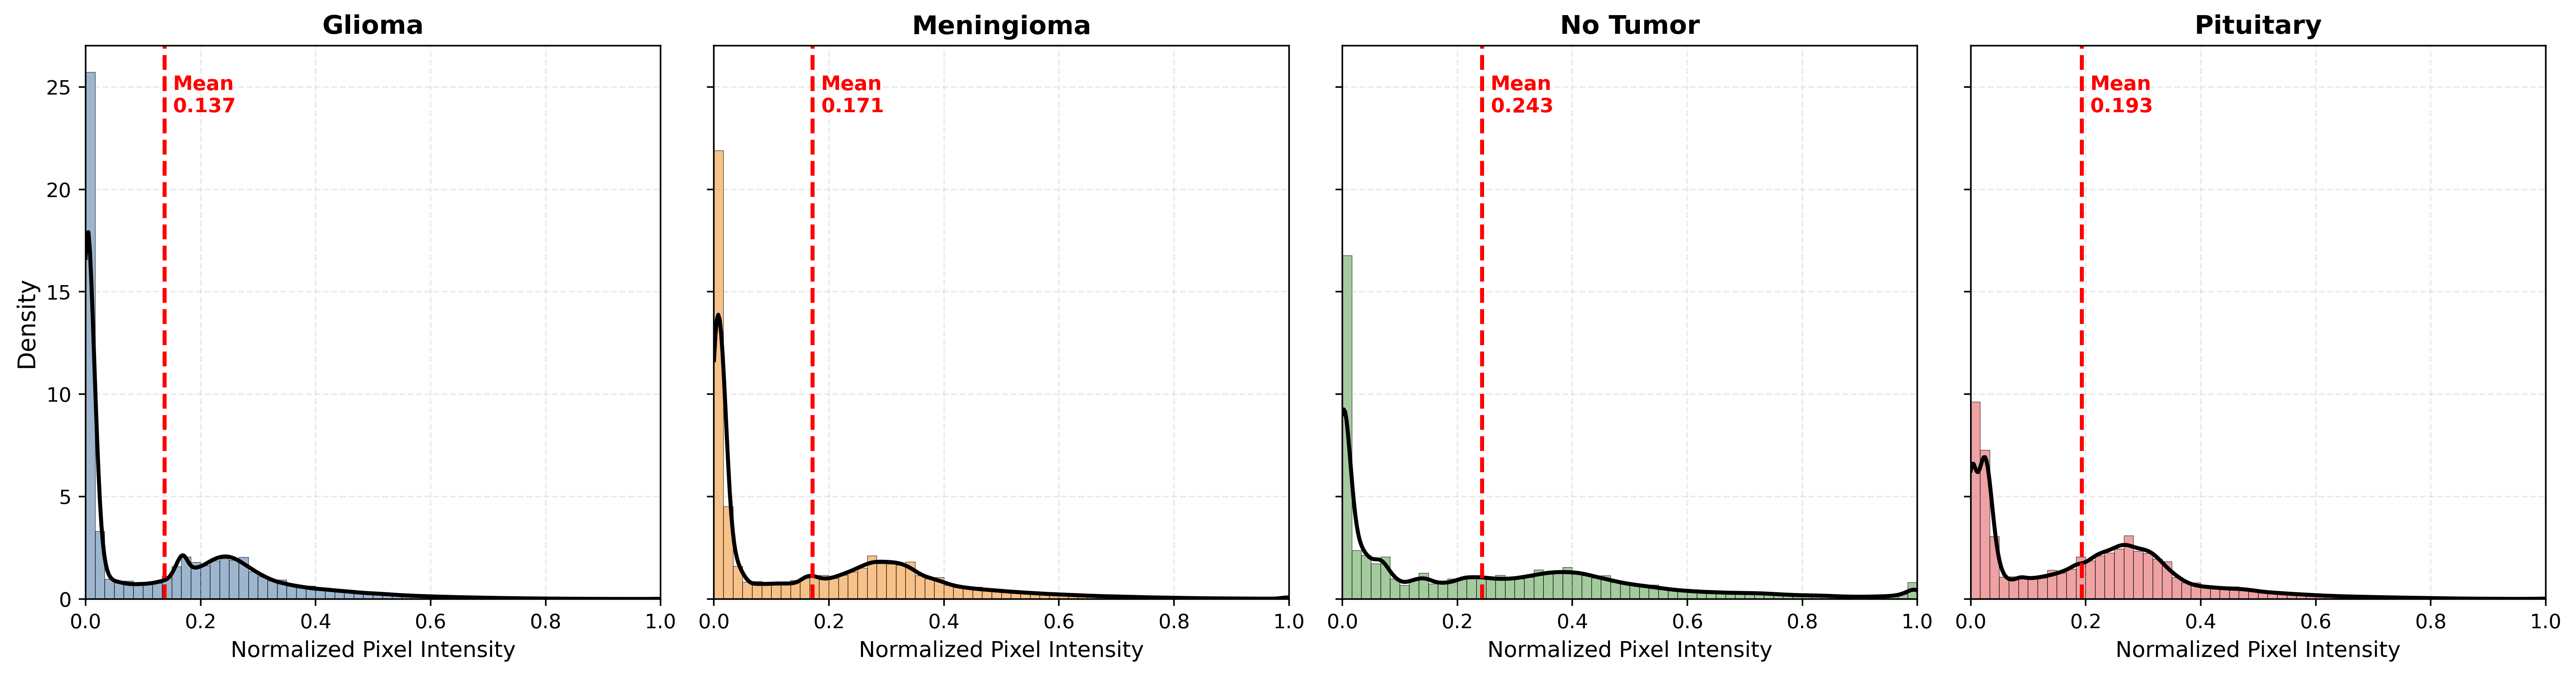


Class-wise Mean Intensity

glioma      : 0.137
meningioma  : 0.171
no_tumor    : 0.243
pituitary   : 0.193


In [15]:
# ==========================================================
# Publication Quality Pixel Intensity Distribution
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import gaussian_kde

N_PER_CLASS = 100

train_df = df[df['split'] == 'train']

intensity_samples = {}

for cls in CLASSES:

    paths = train_df[train_df['class'] == cls]['filepath'].sample(
        min(N_PER_CLASS,
            len(train_df[train_df['class']==cls])),
        random_state=42
    )

    pixels = []

    for p in paths:

        img = (
            Image.open(p)
            .convert('L')
            .resize((224,224))
        )

        pixels.append(
            np.asarray(img,
                       dtype=np.float32).flatten()/255.0
        )

    intensity_samples[cls] = np.concatenate(pixels)

# ----------------------------------------------------
# Colors
# ----------------------------------------------------

colors = [
    "#4E79A7",
    "#F28E2B",
    "#59A14F",
    "#E15759"
]

plt.style.use("default")

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18,4.8),
    dpi=400,
    sharey=True
)

class_means = {}

for ax, cls, color in zip(
        axes,
        CLASSES,
        colors):

    vals = intensity_samples[cls]

    mean_val = vals.mean()

    class_means[cls] = mean_val

    # Histogram (density normalized)
    ax.hist(
        vals,
        bins=60,
        density=True,
        color=color,
        alpha=0.55,
        edgecolor="black",
        linewidth=0.35
    )

    # KDE curve
    kde = gaussian_kde(vals)

    x = np.linspace(0,1,400)

    ax.plot(
        x,
        kde(x),
        color="black",
        linewidth=2
    )

    # Mean line
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2
    )

    # Mean label
    ax.text(
        mean_val+0.015,
        ax.get_ylim()[1]*0.88,
        f"Mean\n{mean_val:.3f}",
        color="red",
        fontsize=10,
        fontweight="bold"
    )

    ax.set_xlim(0,1)

    ax.set_title(
        cls.replace("_"," ").title(),
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Normalized Pixel Intensity",
        fontsize=11
    )

    ax.grid(
        alpha=0.25,
        linestyle="--"
    )

axes[0].set_ylabel(
    "Density",
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "Publication_Pixel_Intensity_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nClass-wise Mean Intensity\n")

for cls,m in class_means.items():
    print(f"{cls:12s}: {m:.3f}")

## Step 6E — Class-wise mean images

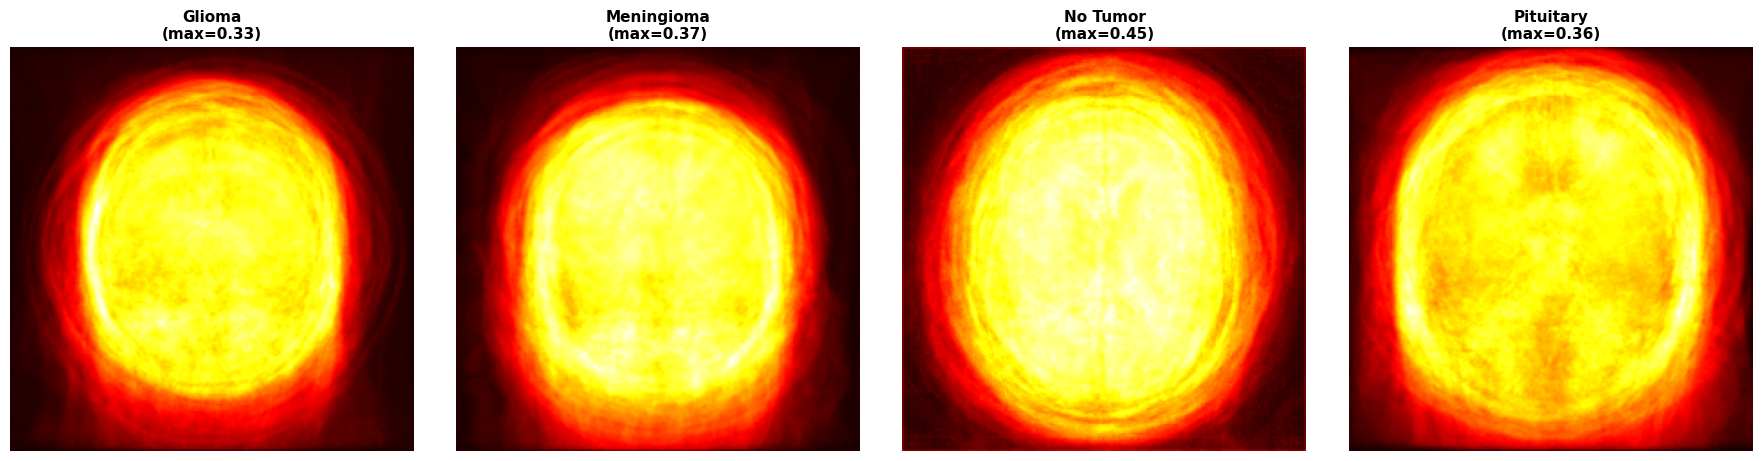

Class-wise mean image peak intensity:
  glioma: 0.332
  meningioma: 0.370
  no_tumor: 0.453
  pituitary: 0.364


In [12]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(4.5 * len(CLASSES), 4.5))
mean_img_peaks = {}
for ax, cls in zip(axes, CLASSES):
    paths = train_df[train_df['class'] == cls]['filepath'].sample(
        min(N_PER_CLASS, len(train_df[train_df['class'] == cls])), random_state=42
    )
    stack = np.stack([
        np.asarray(Image.open(p).convert('L').resize((224, 224)), dtype=np.float32) / 255.0
        for p in paths
    ])
    mean_img = stack.mean(axis=0)
    mean_img_peaks[cls] = mean_img.max()
    im = ax.imshow(mean_img, cmap='hot', vmin=0, vmax=mean_img.max())
    ax.set_title(f"{cls.replace('_',' ').title()}\n(max={mean_img.max():.2f})", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('Class_wise_Mean_MRI_Iamges.png', dpi=200, bbox_inches='tight')
plt.show()

print("Class-wise mean image peak intensity:")
for cls, m in mean_img_peaks.items():
    print(f"  {cls}: {m:.3f}")

## Step 6F — Image quality metrics (contrast, sharpness, SNR)

/tmp/ipykernel_7506/4044801470.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace('_', ' ').title() for c in CLASSES])
/tmp/ipykernel_7506/4044801470.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace('_', ' ').title() for c in CLASSES])
/tmp/ipykernel_7506/4044801470.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace('_', ' ').title() for c in CLASSES])


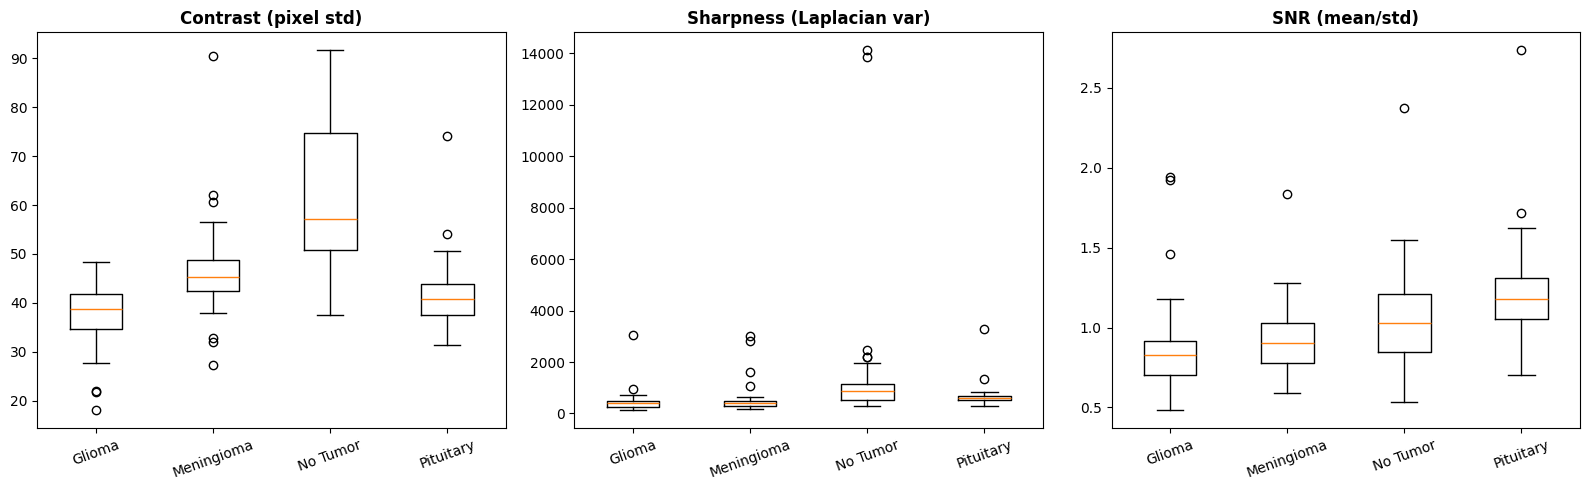

Median quality metrics per class:
             contrast   sharpness    snr
class                                   
glioma      38.817001  405.760986  0.827
meningioma  45.249001  388.726990  0.901
no_tumor    57.207001  863.745972  1.026
pituitary   40.736000  601.434998  1.179


In [13]:
from scipy.ndimage import laplace

N_QUALITY = 50  # matches original methodology

def quality_metrics(path):
    img = np.asarray(Image.open(path).convert('L').resize((224, 224)), dtype=np.float32)
    contrast = img.std()
    sharpness = laplace(img).var()
    mean_val = img.mean()
    snr = mean_val / (img.std() + 1e-8)
    return contrast, sharpness, snr

quality_rows = []
for cls in CLASSES:
    paths = train_df[train_df['class'] == cls]['filepath'].sample(
        min(N_QUALITY, len(train_df[train_df['class'] == cls])), random_state=42
    )
    for p in paths:
        c, s, snr = quality_metrics(p)
        quality_rows.append({'class': cls, 'contrast': c, 'sharpness': s, 'snr': snr})

quality_df = pd.DataFrame(quality_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('contrast', 'Contrast (pixel std)'), ('sharpness', 'Sharpness (Laplacian var)'), ('snr', 'SNR (mean/std)')]
for ax, (col, title) in zip(axes, metrics):
    data = [quality_df[quality_df['class'] == cls][col].values for cls in CLASSES]
    ax.boxplot(data, labels=[c.replace('_', ' ').title() for c in CLASSES])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('Image_Quality_Metrics_per_Class.png', dpi=200, bbox_inches='tight')
plt.show()

print("Median quality metrics per class:")
print(quality_df.groupby('class')[['contrast', 'sharpness', 'snr']].median().round(3))

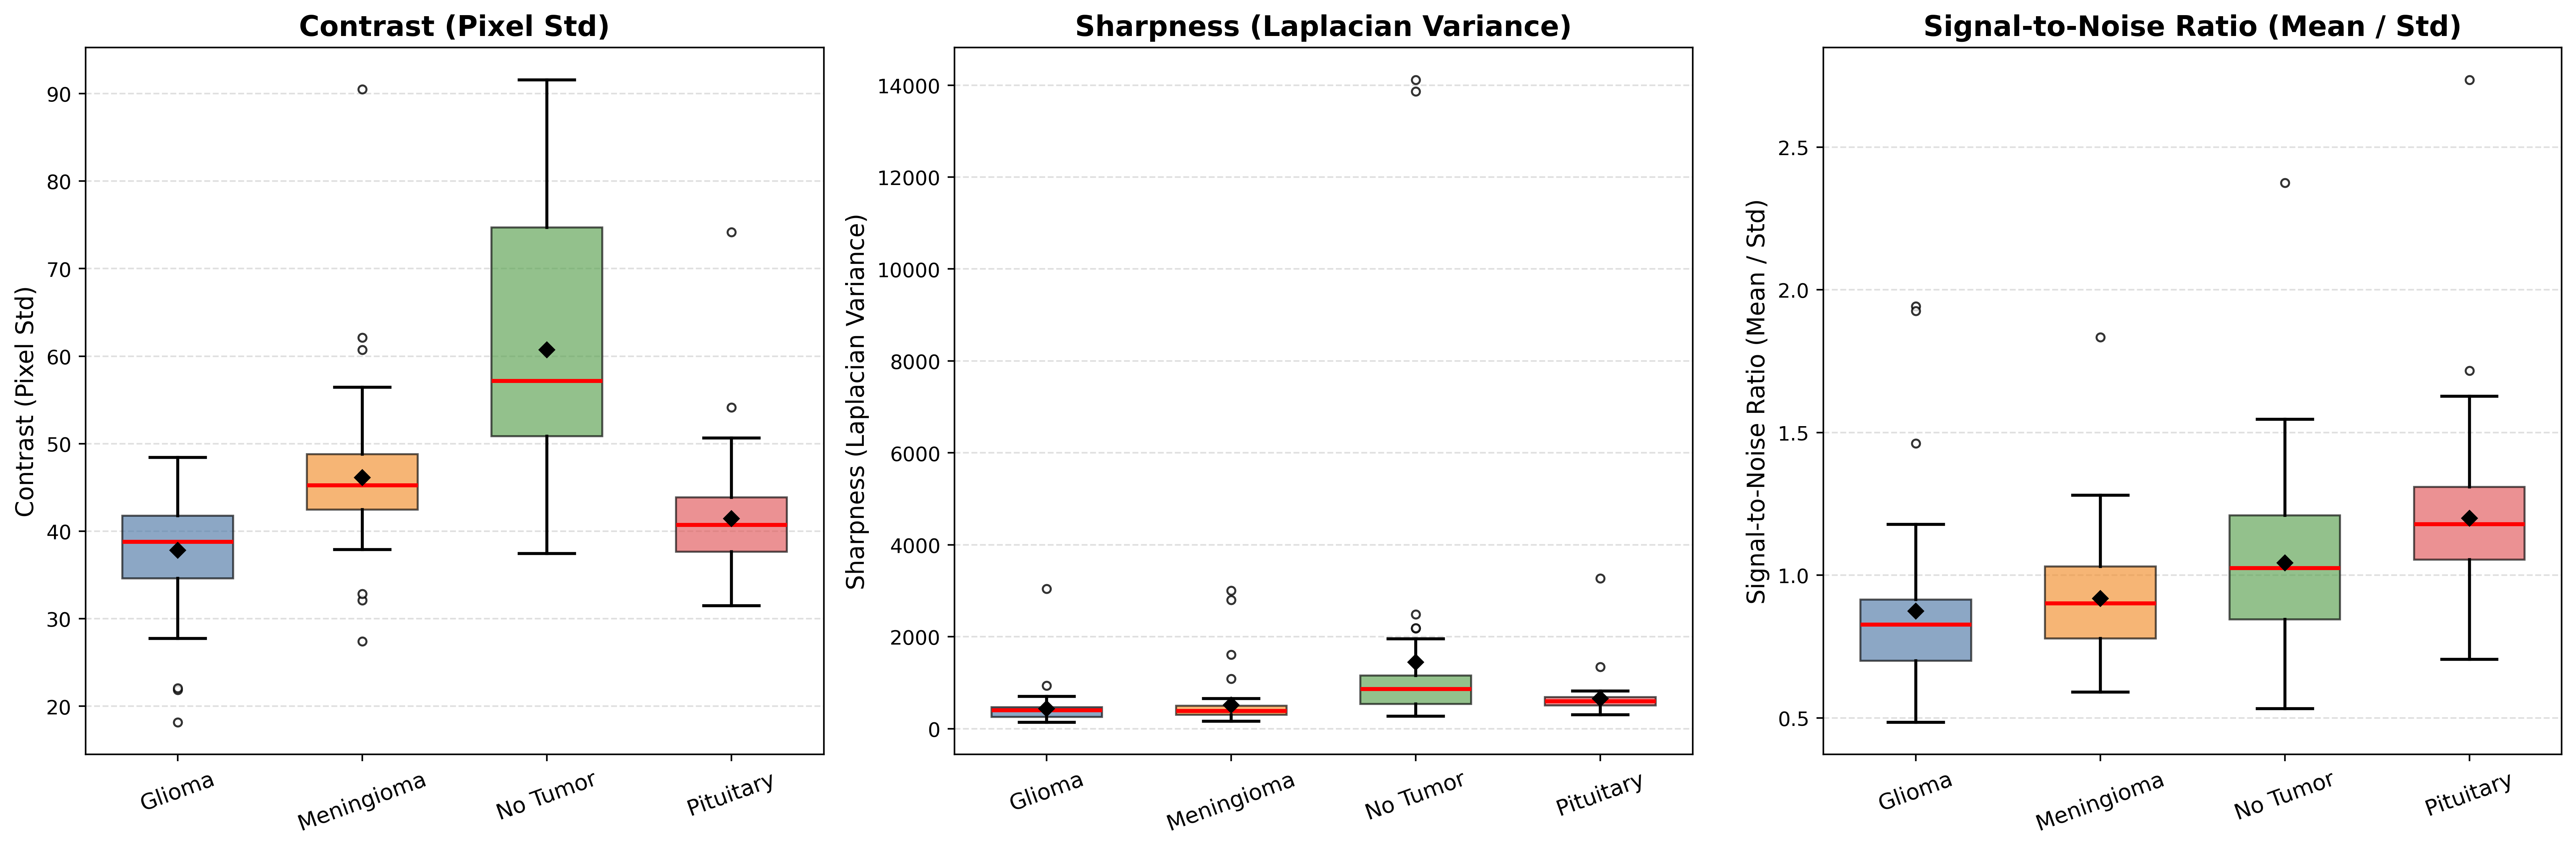

In [14]:
# ===========================================
# Publication Quality Boxplots
# ===========================================

import matplotlib.pyplot as plt

plt.style.use('default')

metrics = [
    ('contrast', 'Contrast (Pixel Std)'),
    ('sharpness', 'Sharpness (Laplacian Variance)'),
    ('snr', 'Signal-to-Noise Ratio (Mean / Std)')
]

colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,6),
    dpi=400
)

for ax, (col, title) in zip(axes, metrics):

    data = [
        quality_df[quality_df['class']==cls][col]
        for cls in CLASSES
    ]

    bp = ax.boxplot(
        data,
        tick_labels=[
            c.replace('_',' ').title()
            for c in CLASSES
        ],
        patch_artist=True,
        widths=0.6,
        showmeans=True,

        meanprops=dict(
            marker='D',
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=5
        ),

        medianprops=dict(
            color='red',
            linewidth=2
        ),

        whiskerprops=dict(
            linewidth=1.5
        ),

        capprops=dict(
            linewidth=1.5
        ),

        flierprops=dict(
            marker='o',
            markersize=4,
            markerfacecolor='white',
            markeredgecolor='black',
            alpha=0.8
        )
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    ax.set_ylabel(title, fontsize=12)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    ax.tick_params(
        axis='x',
        rotation=20,
        labelsize=11
    )

plt.tight_layout()

plt.savefig(
    "Publication_Boxplots.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# The end of Analysis

## Step 8 — Regenerate the dataset card (`README.md`)

Fill in the bracketed placeholders (license, citation, contact) before publishing.


In [ ]:
readme_text = f'''# Brain Tumor MRI Dataset (Glioma, Meningioma, Pituitary, No Tumor)

## Overview
- **Task**: Multi-class brain tumor classification from MRI images
- **Classes**: {', '.join(c.capitalize() for c in CLASSES)}
- **Total images**: {total_images}
- **Split**: Train {split_totals.get('train', 0)} ({split_pcts.get('train', 0)}%) /
  Val {split_totals.get('val', 0)} ({split_pcts.get('val', 0)}%) /
  Test {split_totals.get('test', 0)} ({split_pcts.get('test', 0)}%), stratified per class
- **Source**: Epic & CSCR Hospital [add full attribution / consent statement here]
- **License**: [FILL IN — e.g. CC BY-NC 4.0]
- **Citation**: [FILL IN — how you'd like this dataset cited]

## Integrity
- Verified **zero image-content overlap** between Train/Val/Test (MD5 content hash).
- Verified zero remaining exact-duplicate files.

## Class distribution

{counts.to_markdown()}

## Baseline model benchmark
Reported on the Test split described above.

{results_df.to_markdown(index=False)}

## Directory structure
```
{os.path.basename(DATASET_ROOT)}/
    train/
        glioma/
        meningioma/
        pituitary/
        no_tumor/
    val/
        ...
    test/
        ...
```
'''

with open(os.path.join(DATASET_ROOT, 'README.md'), 'w') as f:
    f.write(readme_text)

counts.to_csv(os.path.join(DATASET_ROOT, 'class_distribution.csv'))
results_df.to_csv(os.path.join(DATASET_ROOT, 'model_benchmark.csv'), index=False)
shutil.copy2('final_dataset_distribution.png', os.path.join(DATASET_ROOT, 'final_dataset_distribution.png'))
shutil.copy2('split_balance_per_class.png', os.path.join(DATASET_ROOT, 'split_balance_per_class.png'))
shutil.copy2('model_benchmark.png', os.path.join(DATASET_ROOT, 'model_benchmark.png'))

print("✅ README.md, class_distribution.csv, model_benchmark.csv, and figures written into the dataset folder")


✅ README.md, class_distribution.csv, model_benchmark.csv, and figures written into the dataset folder


## Step 9 — (Optional) Re-zip and download

Only needed if you want a fresh zip that includes the updated README/analysis
files alongside the images.


In [ ]:
zip_path = shutil.make_archive('Brain_Tumor_MRI_Dataset_Final_with_Analysis', 'zip', DATASET_ROOT)
print(f"✅ Created {zip_path}  ({os.path.getsize(zip_path) / (1024**2):.1f} MB)")

files.download(zip_path)
